In [1]:
!pip install textblob matplotlib pandas
!python -m textblob.download_corpora


[nltk_data] Downloading package brown to /root/nltk_data...
[nltk_data]   Unzipping corpora/brown.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.
[nltk_data] Downloading package conll2000 to /root/nltk_data...
[nltk_data]   Unzipping corpora/conll2000.zip.
[nltk_data] Downloading package movie_reviews to /root/nltk_data...
[nltk_data]   Unzipping corpora/movie_reviews.zip.
Finished.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Simulate daily dates for 2023
dates = pd.date_range(start='2023-01-01', end='2023-12-31', freq='D')

# Simulate price data: random walk with slight upward trend
np.random.seed(42)
price = np.cumsum(np.random.randn(len(dates)) * 2 + 0.1) + 75

# Create DataFrame
df = pd.DataFrame({'Date': dates, 'Price': price})
df.set_index('Date', inplace=True)

# Preview
df.head()


,Price
Date,
2023-01-01,76.093428
2023-01-02,75.916900
2023-01-03,77.312277
2023-01-04,80.458336
2023-01-05,80.090030


In [4]:
def compute_rsi(data, period=14):
    delta = data['Price'].diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)
    avg_gain = gain.rolling(window=period).mean()
    avg_loss = loss.rolling(window=period).mean()
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    data['RSI'] = rsi
    return data


In [5]:
def compute_macd(data):
    ema_12 = data['Price'].ewm(span=12, adjust=False).mean()
    ema_26 = data['Price'].ewm(span=26, adjust=False).mean()
    macd = ema_12 - ema_26
    signal = macd.ewm(span=9, adjust=False).mean()
    data['MACD'] = macd
    data['Signal'] = signal
    return data


In [7]:
df = compute_rsi(df)
df = compute_macd(df)


In [8]:
from textblob import TextBlob

# Sample news data for a few random dates
news_data = {
    'Date': ['2023-03-15', '2023-05-10', '2023-08-25', '2023-10-10', '2023-12-01'],
    'Headline': [
        'Oil prices surge after OPEC supply cut announcement',
        'Crude oil dips as US stockpiles increase unexpectedly',
        'Middle East conflict threatens global oil supply',
        'Falling demand slows crude oil rally',
        'Supply chain recovery boosts global oil trade'
    ]
}

news_df = pd.DataFrame(news_data)
news_df['Date'] = pd.to_datetime(news_df['Date'])


In [9]:
# Sentiment polarity: -1 (negative) to +1 (positive)
news_df['Sentiment'] = news_df['Headline'].apply(lambda x: TextBlob(x).sentiment.polarity)

# Group by date to compute daily average sentiment
daily_sentiment = news_df.groupby('Date')['Sentiment'].mean().rename('Daily_Sentiment')


In [10]:
df = df.merge(daily_sentiment, left_index=True, right_index=True, how='left')
df['Daily_Sentiment'].fillna(0, inplace=True)  # fill missing days with neutral sentiment


/tmp/ipython-input-10-465444371.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Daily_Sentiment'].fillna(0, inplace=True)  # fill missing days with neutral sentiment


In [12]:
df['Daily_Sentiment'] = df['Daily_Sentiment'].fillna(0)


In [13]:
# Initialize Trade_Signal column
df['Trade_Signal'] = 0

# Buy Signal
df.loc[
    (df['RSI'] < 40) &
    (df['MACD'] > df['Signal']) &
    (df['Daily_Sentiment'] > 0),
    'Trade_Signal'
] = 1

# Sell Signal
df.loc[
    (df['RSI'] > 60) &
    (df['MACD'] < df['Signal']) &
    (df['Daily_Sentiment'] < 0),
    'Trade_Signal'
] = -1


In [14]:
print("Buy Signals:", (df['Trade_Signal'] == 1).sum())
print("Sell Signals:", (df['Trade_Signal'] == -1).sum())


Buy Signals: 0
Sell Signals: 0


In [15]:
# Reset signal column
df['Trade_Signal'] = 0

# Relaxed Buy: RSI < 50, MACD > Signal, Sentiment ≥ 0
df.loc[
    (df['RSI'] < 50) &
    (df['MACD'] > df['Signal']) &
    (df['Daily_Sentiment'] >= 0),
    'Trade_Signal'
] = 1

# Relaxed Sell: RSI > 50, MACD < Signal, Sentiment ≤ 0
df.loc[
    (df['RSI'] > 50) &
    (df['MACD'] < df['Signal']) &
    (df['Daily_Sentiment'] <= 0),
    'Trade_Signal'
] = -1


In [16]:
print("Buy Signals:", (df['Trade_Signal'] == 1).sum())
print("Sell Signals:", (df['Trade_Signal'] == -1).sum())


Buy Signals: 12
Sell Signals: 44


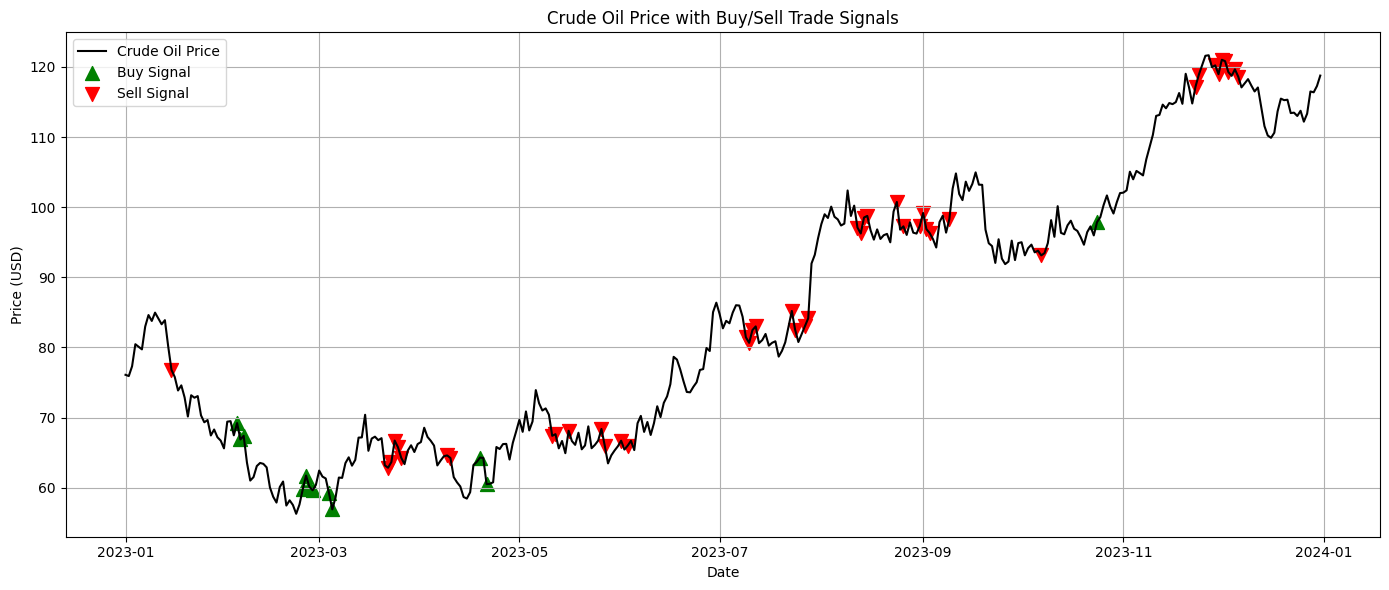

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

# Plot price
plt.plot(df.index, df['Price'], label='Crude Oil Price', color='black')

# Buy markers (green upward triangle)
plt.scatter(df[df['Trade_Signal'] == 1].index,
            df[df['Trade_Signal'] == 1]['Price'],
            label='Buy Signal', color='green', marker='^', s=100)

# Sell markers (red downward triangle)
plt.scatter(df[df['Trade_Signal'] == -1].index,
            df[df['Trade_Signal'] == -1]['Price'],
            label='Sell Signal', color='red', marker='v', s=100)

# Labels and legend
plt.title('Crude Oil Price with Buy/Sell Trade Signals')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
